# Exploratory Data Analysis (EDA) – First Quarter Sales Dataset

## Project Overview

This notebook presents an exploratory data analysis (EDA) of the cleaned first-quarter sales dataset. The analysis aims to explore sales performance, product trends, temporal patterns, and delivery platform performance by applying descriptive statistics and visualizations. The findings provide valuable insights into business performance and establish a foundation for dashboard development and quarterly comparisons.

## Objectives

The main objectives of this analysis are:

- Evaluate the overall sales performance during the first quarter.
- Analyze product performance based on revenue, sales quantity, and product returns.
- Identify sales trends across months, weekdays, and hours.
- Evaluate the performance of the major delivery platforms.
- Discover patterns and business insights through descriptive analysis and visualizations.
- Summarize the key findings to support business decision-making and prepare for quarterly and yearly comparisons.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Clean Dataset

Load the cleaned first-quarter sales dataset and verify its structure before starting the exploratory data analysis.

In [2]:
df = pd.read_excel("../../../Data/Cleaned/clean_q1_data.xlsx", parse_dates=["Date"])

## 3. Dataset Overview

This section provides a general overview of the cleaned dataset, including its dimensions, data types, descriptive statistics, and basic business metrics.

### 3.1 Dataset Shape

In [3]:
df.shape

(41840, 8)

### 3.2 Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41840 entries, 0 to 41839
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            41840 non-null  datetime64[ns]
 1   Receipt Number  41840 non-null  object        
 2   Customer        6295 non-null   object        
 3   Product         41840 non-null  object        
 4   Quantity        41840 non-null  float64       
 5   Unit_Price      41840 non-null  float64       
 6   Subtotal        41840 non-null  float64       
 7   Total           15400 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 2.6+ MB


### 3.3 Descriptive Statistics

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,41840,2025-02-07 01:25:19.715654912,2025-01-01 06:09:10,2025-01-19 07:39:15,2025-02-05 21:28:47,2025-02-22 19:34:10,2025-03-31 23:49:41,NaN
Quantity,41840.0,1.661436,-15.0,1.0,1.0,2.0,460.0,4.20725
Unit_Price,41840.0,10.829134,0.55,4.0,6.0,12.0,138.0,12.395738
Subtotal,41840.0,14.580702,-218.5,4.0,10.0,20.0,2760.0,26.031861
Total,15400.0,39.620427,-539.2,11.0,24.0,53.0,2760.0,55.31981


### 3.4 Missing Values Check

In [6]:
df.isna().sum()

Date                  0
Receipt Number        0
Customer          35545
Product               0
Quantity              0
Unit_Price            0
Subtotal              0
Total             26440
dtype: int64

> **Note:** The missing values in the **Customer** and **Total** columns are expected and do not indicate data quality issues. Customer information is only recorded for transactions associated with registered customers or delivery applications, while many in-store transactions do not contain customer names. Similarly, the **Total** value represents the overall amount of an entire receipt and is intentionally stored only once for each transaction rather than being repeated for every product line. Therefore, these missing values were retained as they accurately reflect the original transaction structure.

### 3.5 Duplicate Records Check

In [7]:
df.duplicated().sum()

np.int64(0)

### 3.6 Date Range

In [8]:
print(df["Date"].min())
print(df["Date"].max())

2025-01-01 06:09:10
2025-03-31 23:49:41


### 3.7 Business Summary

In [9]:
print(f"Total Records : {len(df):,}")
print(f"Unique Orders : {df['Receipt Number'].nunique():,}")
print(f"Unique Products : {df['Product'].nunique():,}")
print(f"Unique Customers : {df['Customer'].nunique():,}")

Total Records : 41,840
Unique Orders : 15,406
Unique Products : 171
Unique Customers : 828


## 4. Sales Performance Analysis

This section evaluates the overall sales performance during the first quarter by calculating key business metrics. These key performance indicators (KPIs) provide an overview of the sales volume, revenue, and transaction characteristics, serving as a foundation for the subsequent analyses.

### 4.1 Total Revenue

In [10]:
total_revenue = df["Subtotal"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 610,056.57


### 4.2 Total Quantity Sold

In [11]:
total_quantity = df["Quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,.0f}")

Total Quantity Sold: 69,514


### 4.3 Total Orders

In [12]:
total_orders = df["Receipt Number"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 15,406


### 4.4 Average Order Value (AOV)

In [13]:
average_order_value = (
    df.groupby("Receipt Number")["Subtotal"]
      .sum()
      .mean()
)

print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 39.60


### 4.5 Average Selling Price

In [14]:
average_price = df["Unit_Price"].mean()

print(f"Average Selling Price: {average_price:.2f}")

Average Selling Price: 10.83


### 4.6 Average Items per Order

In [15]:
average_items = (
    df.groupby("Receipt Number")["Quantity"]
      .sum()
      .mean()
)

print(f"Average Items per Order: {average_items:.2f}")

Average Items per Order: 4.51


### 4.7 Summary Table

In [16]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Orders",
        "Average Order Value",
        "Average Selling Price",
        "Average Items per Order"
    ],
    "Value": [
        round(total_revenue, 2),
        int(total_quantity),
        total_orders,
        round(average_order_value, 2),
        round(average_price, 2),
        round(average_items, 2)
    ]
})

sales_summary

,Metric,Value
0,Total Revenue,610056.57
1,Total Quantity Sold,69514.00
2,Total Orders,15406.00
3,Average Order Value,39.60
4,Average Selling Price,10.83
5,Average Items per Order,4.51


## 5. Product Analysis

This section evaluates product performance by examining the number of unique products, sales volume, revenue contribution, and product returns. The analysis helps identify the best-performing products, the lowest-selling products, and the products with the highest number of returned items during the first quarter.

### 5.1 Number of Unique Products

Calculate the total number of unique products available in the dataset.

In [17]:
unique_products = df["Product"].nunique()

print(f"Unique Products: {unique_products}")

Unique Products: 171


### 5.2 Top Products by Revenue

Identify the products that generated the highest revenue.

In [18]:
top_revenue_products = (
    df.groupby("Product")["Subtotal"]
      .sum()
      .sort_values(ascending=False)
)

top_revenue_products.head(10)

Product
صحن تكا روب          30097.00
سيخ تكا روب          29773.00
هريس لحم صغير        25098.00
صحن سبشل تكا         23596.80
باجا كوارع           21017.00
صاروخ تكا لحم روب    18372.64
صحن 21 سيخ مشكل      16452.00
حمص                  16131.00
صحن تكا ليمون        15992.68
باجا مشكل صغير       14537.00
Name: Subtotal, dtype: float64

### 5.3 Top Products by Quantity Sold

Identify the products with the highest sales volume.

In [19]:
top_quantity_products = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_quantity_products.head(10)

Product
خبز عربي تنور        7682.0
سيخ تكا روب          5933.0
هريس لحم صغير        2489.0
ماء                  2353.0
سيخ تكا ليمون        2280.0
كينزا كولا           2255.0
سندويش كبدة          2232.0
سندويش بيض بالجبن    2190.0
سيخ تكا دجاج         1829.0
سندويش فلافل         1732.0
Name: Quantity, dtype: float64

### 5.4 Lowest-Selling Products

Identify the products with the lowest sales volume.

In [20]:
lowest_products = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=True)
)

lowest_products.head(10)

Product
نص صحن فول              1.0
كبة جبن                 1.0
كريم كراميل             2.0
صحن رمضاني مشكل صغير    2.0
سندويش فلافل لبنة       3.0
محاشي                   3.0
صحن لحم مفروم بالجين    4.0
دلة شاي                 4.0
كبسة حاشي نفرين         4.0
خبز زعتر بالخضار        4.0
Name: Quantity, dtype: float64

### 5.5 Most Returned Products

Identify the products with the highest number of returned items based on negative sales quantities.


In [21]:
returned_products = (
    df[df["Quantity"] < 0]
      .groupby("Product")["Quantity"]
      .sum()
      .abs()
      .sort_values(ascending=False)
)

returned_products.head(10)

Product
ماء                33.0
خبز عربي تنور      30.0
كينزا كولا         23.0
سيخ تكا روب        18.0
حمص                12.0
صاروخ كباب دجاج    12.0
باجا كوارع         11.0
سندويش كبدة        10.0
سندويش فلافل        9.0
سيخ تكا دجاج        9.0
Name: Quantity, dtype: float64

### 5.6 Product Performance Summary

Summarize the overall performance of each product, including total revenue, quantity sold, and average selling price.

In [22]:
product_summary = (
    df.groupby("Product")
      .agg(
          Revenue=("Subtotal", "sum"),
          Quantity_Sold=("Quantity", "sum"),
          Average_Price=("Unit_Price", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

product_summary

,Revenue,Quantity_Sold,Average_Price
Product,,,
صحن تكا روب,30097.0,1059.0,28.386082
سيخ تكا روب,29773.0,5933.0,5.026198
هريس لحم صغير,25098.0,2489.0,10.089911
صحن سبشل تكا,23596.8,477.0,49.470938
باجا كوارع,21017.0,1047.0,20.089862
...,...,...,...
خبز بر,25.0,25.0,1.000000
سندويش فلافل لبنة,18.0,3.0,6.000000
خبز زعتر بالخضار,16.0,4.0,4.000000


## 6. Time-Based Analysis

This section analyzes sales performance over time by examining revenue and transaction patterns across different months, weekdays, and hours. The objective is to identify sales trends and peak business periods during the first quarter.

### 6.1 Date Features

Extract additional date and time features from the transaction date to support the time-based analysis.

In [23]:
# Extract useful date and time features.
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Month_Number"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()
df["Hour"] = df["Date"].dt.hour

### 6.2 Sales by Month

Analyze the monthly sales revenue to identify sales trends throughout the quarter.

In [24]:
monthly_sales = (
    df.groupby(["Month_Number", "Month"], as_index=False)["Subtotal"]
      .sum()
      .sort_values("Month_Number")
)

monthly_sales

,Month_Number,Month,Subtotal
0,1,January,257025.21
1,2,February,232426.66
2,3,March,120604.70


### 6.3 Orders by Month

Analyze the number of unique orders placed each month.

In [25]:
monthly_orders = (
    df.groupby(["Month_Number", "Month"], as_index=False)["Receipt Number"]
      .nunique()
      .rename(columns={"Receipt Number": "Orders"})
      .sort_values("Month_Number")
)

monthly_orders

,Month_Number,Month,Orders
0,1,January,6338
1,2,February,5886
2,3,March,3182


### 6.4 Sales by Weekday

Analyze sales revenue across the days of the week to identify the busiest sales days.

In [26]:
weekday_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

df["Weekday"] = pd.Categorical(
    df["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_sales = (
    df.groupby("Weekday", observed=True)["Subtotal"]
      .sum()
      .sort_index()
)

weekday_sales

Weekday
Sunday        76741.78
Monday        90561.44
Tuesday       81380.76
Wednesday     88554.09
Thursday     102485.22
Friday        92966.36
Saturday      77366.92
Name: Subtotal, dtype: float64

### 6.5 Orders by Weekday

Analyze the number of unique orders across the days of the week.

In [27]:
weekday_orders = (
    df.groupby("Weekday", observed=True)["Receipt Number"]
      .nunique()
      .sort_index()
)

weekday_orders

Weekday
Sunday       2149
Monday       2344
Tuesday      2203
Wednesday    2467
Thursday     2500
Friday       1968
Saturday     1775
Name: Receipt Number, dtype: int64

### 6.6 Sales by Hour

Analyze sales revenue by hour to identify peak shopping hours.

In [28]:
hourly_sales = (
    df.groupby("Hour")["Subtotal"]
      .sum()
      .sort_index()
)

hourly_sales

Hour
0     20019.70
1     16934.20
2     15203.00
3      1545.00
4       199.00
5       548.00
6     17101.73
7     30253.40
8     27460.00
9     29448.79
10    21666.05
11     3732.00
12       14.00
14       55.00
15     9736.00
16    19812.00
17    22617.00
18    29918.78
19    58291.78
20    73890.16
21    81837.74
22    71496.84
23    58276.40
Name: Subtotal, dtype: float64

### 6.7 Orders by Hour

Analyze the number of unique orders placed during each hour of the day.

In [29]:
hourly_orders = (
    df.groupby("Hour")["Receipt Number"]
      .nunique()
      .sort_index()
)

hourly_orders

Hour
0      362
1      391
2      272
3       27
4        8
5       21
6      893
7     1525
8     1244
9     1168
10     897
11     204
12       2
14       4
15     379
16     744
17     811
18     651
19     996
20    1231
21    1367
22    1209
23    1000
Name: Receipt Number, dtype: int64

### 6.8 Peak Sales Periods

Identify the month, weekday, and hour with the highest sales revenue and the highest number of orders.

In [30]:
# Peak sales month
peak_month = monthly_sales.loc[
    monthly_sales["Subtotal"].idxmax(),
    "Month"
]

# Peak sales weekday
peak_weekday = weekday_sales.idxmax()

# Peak sales hour
peak_hour = hourly_sales.idxmax()

# Peak orders month
peak_orders_month = monthly_orders.loc[
    monthly_orders["Orders"].idxmax(),
    "Month"
]

# Peak orders weekday
peak_orders_weekday = weekday_orders.idxmax()

# Peak orders hour
peak_orders_hour = hourly_orders.idxmax()

print(f"Peak Sales Month   : {peak_month}")
print(f"Peak Sales Weekday : {peak_weekday}")
print(f"Peak Sales Hour    : {peak_hour}:00\n")

print(f"Peak Orders Month   : {peak_orders_month}")
print(f"Peak Orders Weekday : {peak_orders_weekday}")
print(f"Peak Orders Hour    : {peak_orders_hour}:00")

Peak Sales Month   : January
Peak Sales Weekday : Thursday
Peak Sales Hour    : 21:00

Peak Orders Month   : January
Peak Orders Weekday : Thursday
Peak Orders Hour    : 7:00


## 7. Sales Channel Analysis

This section analyzes the performance of online delivery platforms by evaluating their contribution to sales revenue and transaction volume during the first quarter.

### 7.1 Delivery Platforms

Identify the major delivery platforms included in the analysis. Platforms with only a negligible number of transactions (e.g., a single transaction) are excluded to ensure that the analysis focuses on meaningful sales patterns and avoids misleading comparisons.

In [31]:
delivery_apps = [
    "عملاء شوكة",
    "عملاء هنقرستيشن",
    "عملاء كيتا"
]

platform_df = df[df["Customer"].isin(delivery_apps)]

### 7.2 Revenue by Delivery Platform

Analyze the total sales revenue generated by each delivery platform.

In [32]:
platform_sales = (
    platform_df.groupby("Customer")["Subtotal"]
    .sum()
    .sort_values(ascending=False)
)

platform_sales

Customer
عملاء شوكة         16409.58
عملاء كيتا          3822.16
عملاء هنقرستيشن     3095.00
Name: Subtotal, dtype: float64

### 7.3 Orders by Delivery Platform

Analyze the number of unique orders received from each delivery platform.

In [33]:
platform_orders = (
    platform_df.groupby("Customer")["Receipt Number"]
    .nunique()
    .sort_values(ascending=False)
)

platform_orders

Customer
عملاء شوكة         899
عملاء كيتا         173
عملاء هنقرستيشن     78
Name: Receipt Number, dtype: int64

### 7.4 Average Order Value by Platform

Calculate the average order value for each delivery platform.

In [34]:
platform_aov = (
    platform_df.groupby(["Customer", "Receipt Number"])["Subtotal"]
    .sum()
    .groupby("Customer")
    .mean()
    .sort_values(ascending=False)
)

platform_aov

Customer
عملاء هنقرستيشن    39.679487
عملاء كيتا         22.093410
عملاء شوكة         18.253148
Name: Subtotal, dtype: float64

### 7.5 Revenue Contribution

Calculate the percentage contribution of each delivery platform to the total sales revenue.

In [35]:
platform_contribution = (
    (platform_sales / platform_sales.sum()) * 100
).round(2)

platform_contribution

Customer
عملاء شوكة         70.35
عملاء كيتا         16.39
عملاء هنقرستيشن    13.27
Name: Subtotal, dtype: float64

## 8. Data Visualization

This section presents graphical representations of the key findings obtained from the exploratory data analysis. The visualizations provide an intuitive understanding of sales performance, product trends, time-based patterns, and delivery platform contributions during the first quarter.

### 8.1 Top 10 Products by Revenue

Visualize the ten products that generated the highest sales revenue.

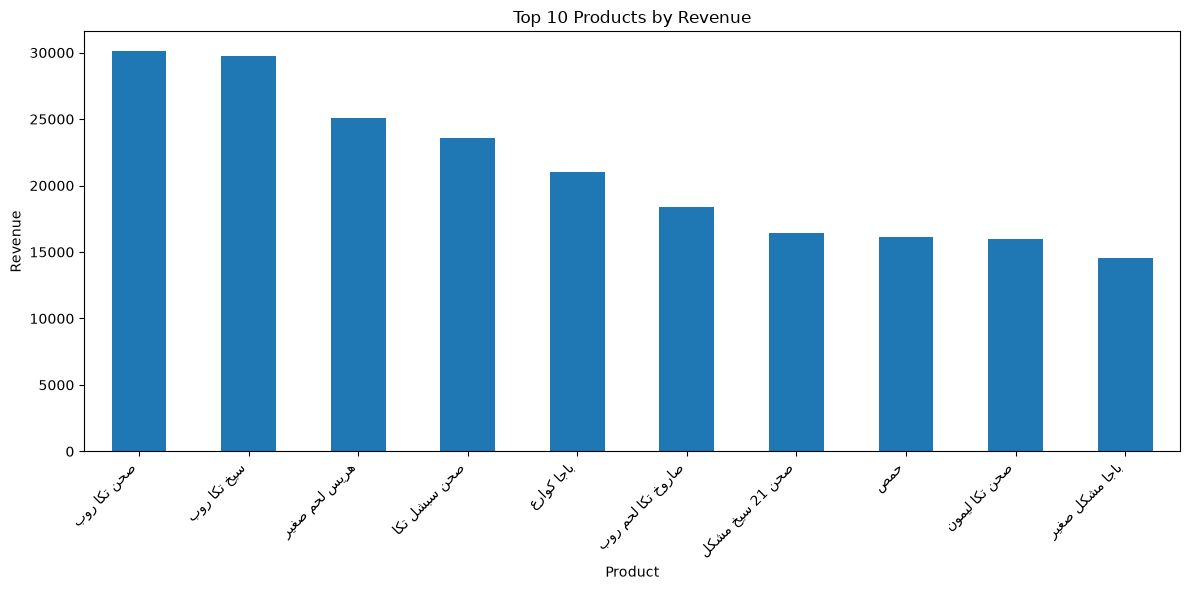

In [36]:
plt.figure(figsize=(12, 6))

top_revenue_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.2 Top 10 Products by Quantity Sold

Visualize the ten products with the highest sales volume.

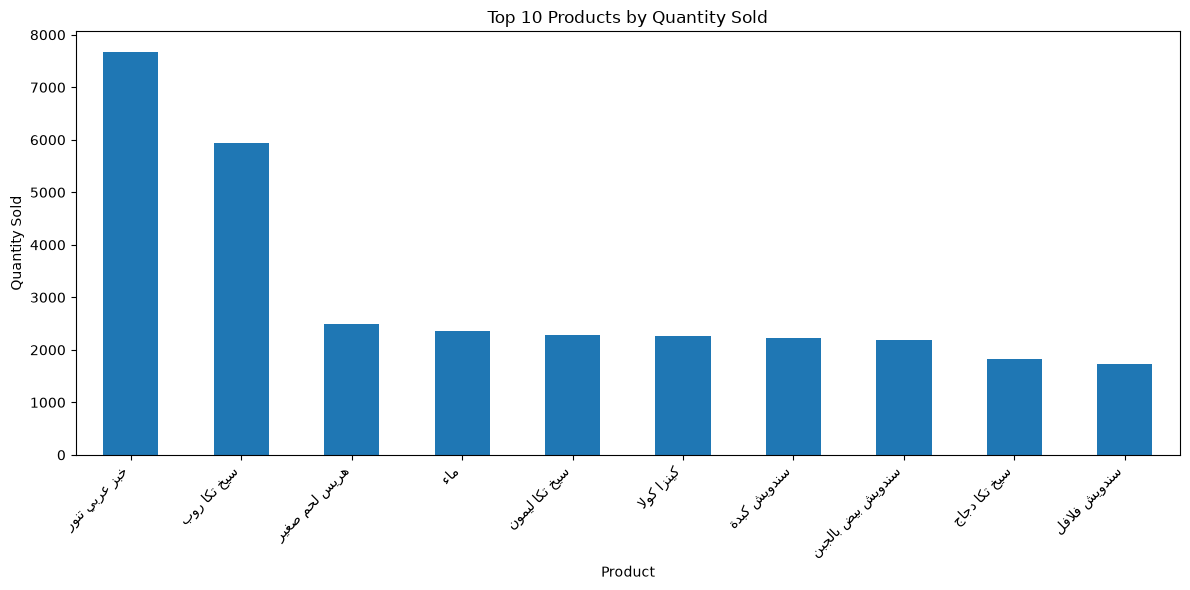

In [37]:
plt.figure(figsize=(12, 6))

top_quantity_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.3 Lowest-Selling Products

Visualize the products with the lowest sales quantity.

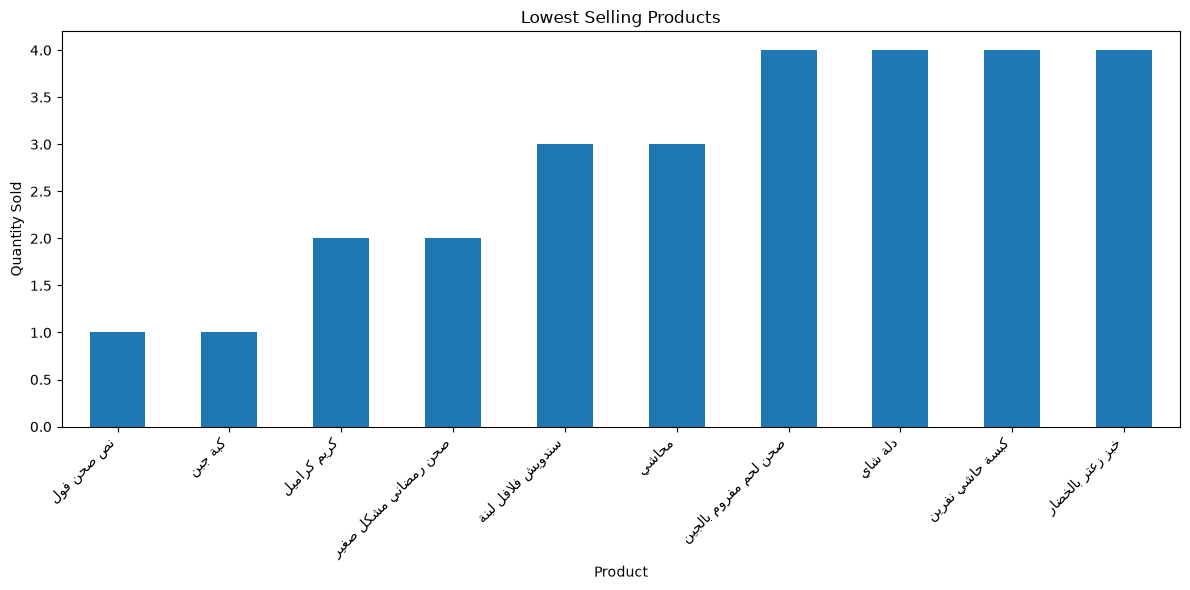

In [38]:
plt.figure(figsize=(12, 6))

lowest_products.head(10).plot(kind="bar")

plt.title("Lowest Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.4 Most Returned Products

Visualize the products with the highest number of returned items.

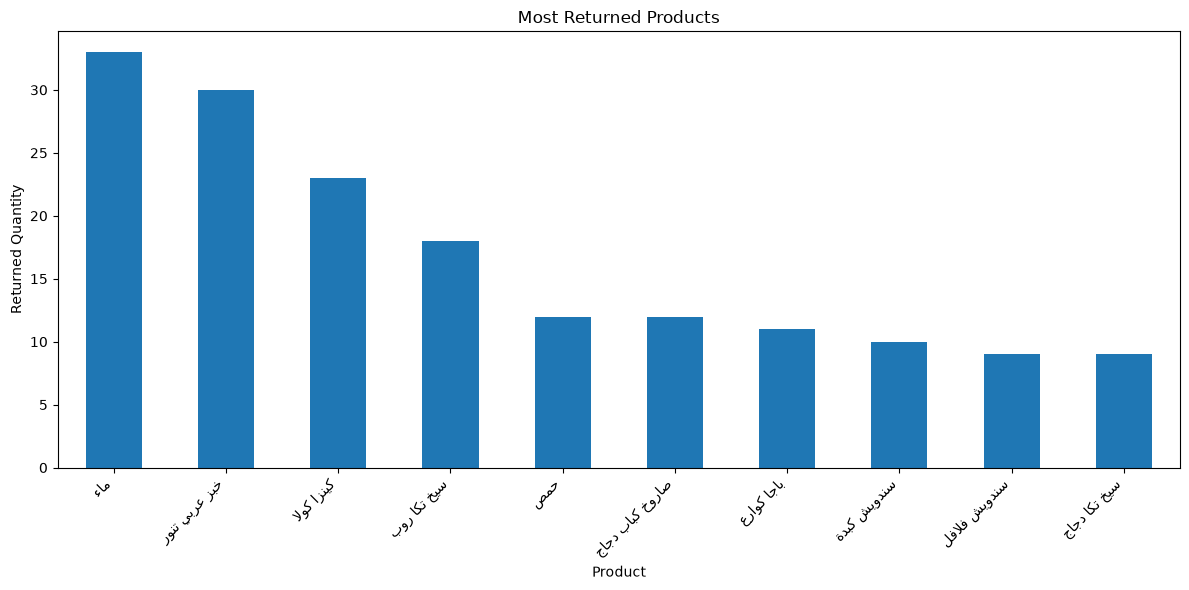

In [39]:
plt.figure(figsize=(12, 6))

returned_products.head(10).plot(kind="bar")

plt.title("Most Returned Products")
plt.xlabel("Product")
plt.ylabel("Returned Quantity")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.5 Monthly Sales

Visualize the total sales revenue for each month.

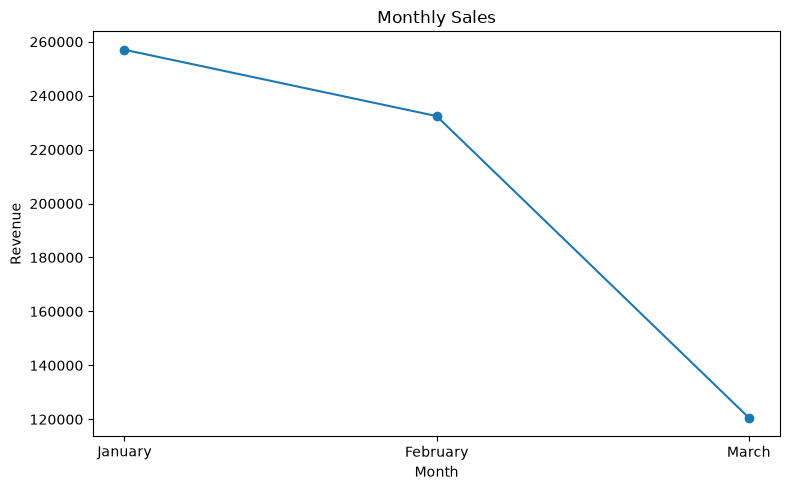

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Subtotal"],
    marker="o"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### 8.6 Sales by Weekday

Visualize sales revenue across the days of the week.

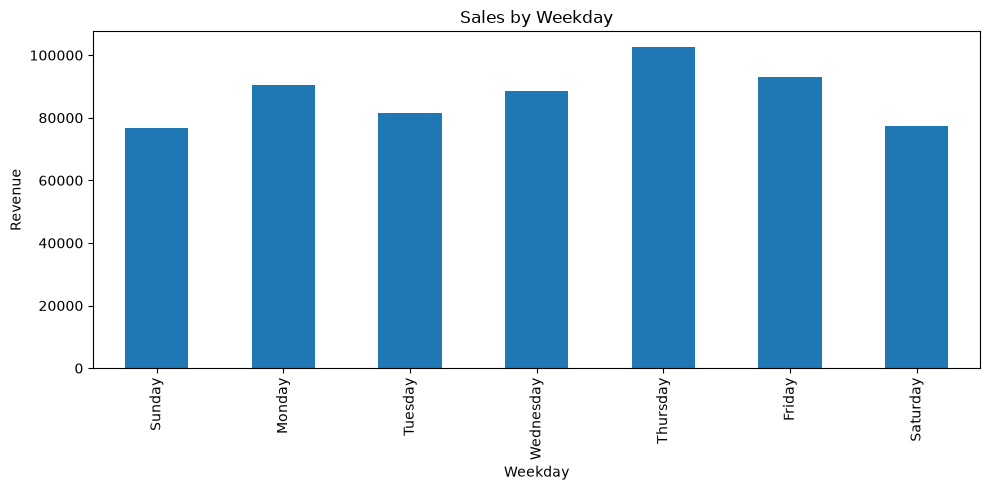

In [41]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### 8.7 Sales by Hour

Visualize hourly sales revenue to identify peak business hours.

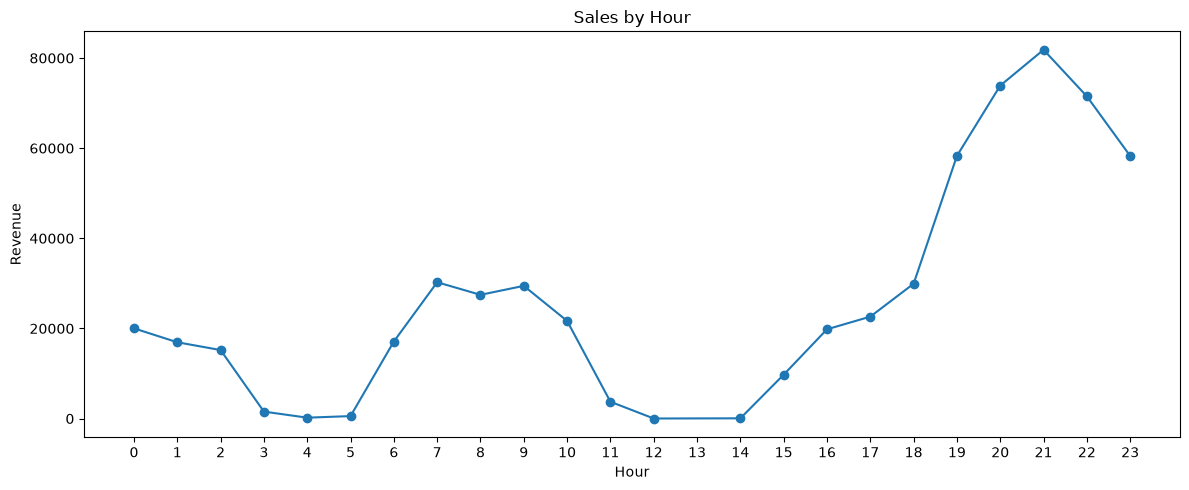

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_sales.index,
    hourly_sales.values,
    marker="o"
)

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

### 8.8 Revenue by Delivery Platform

Visualize the sales revenue generated by each delivery platform.

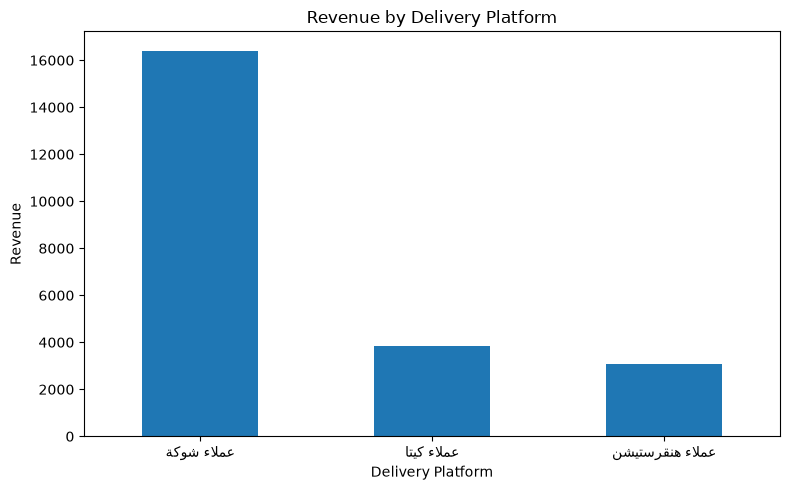

In [43]:
plt.figure(figsize=(8, 5))

platform_sales.plot(kind="bar")

plt.title("Revenue by Delivery Platform")
plt.xlabel("Delivery Platform")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 8.9 Orders by Delivery Platform

Visualize the number of orders received from each delivery platform.

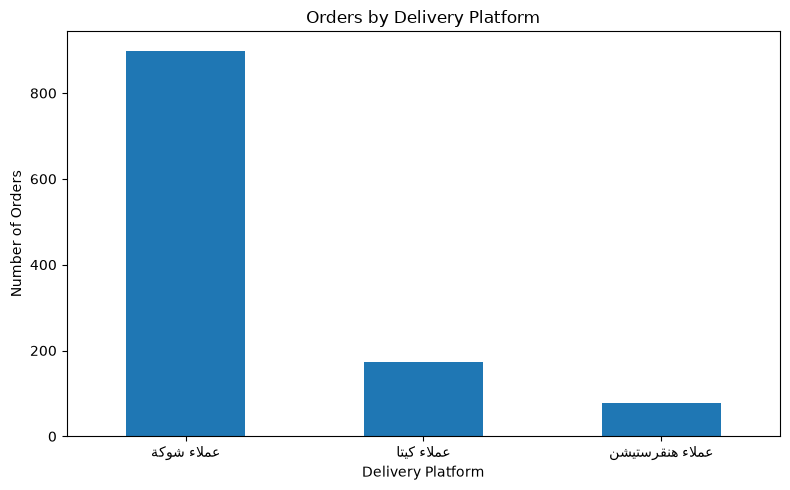

In [44]:
plt.figure(figsize=(8, 5))

platform_orders.plot(kind="bar")

plt.title("Orders by Delivery Platform")
plt.xlabel("Delivery Platform")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 8.10 Delivery Platform Revenue Contribution

Visualize the percentage contribution of each delivery platform to the total sales revenue.

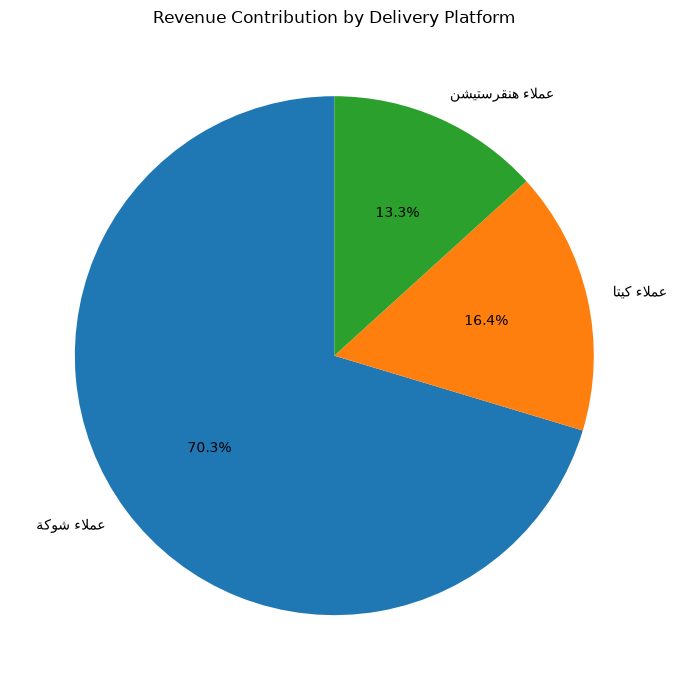

In [45]:
plt.figure(figsize=(7, 7))

plt.pie(
    platform_contribution,
    labels=platform_contribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Delivery Platform")

plt.tight_layout()
plt.show()

## 9. Key Insights

- The first quarter generated a total revenue of **610,056.57** from **15,406** completed orders, with an average order value of **39.60**.
- The cleaned dataset contains **171 unique products**, **828 unique customers**, and **15,406** unique transactions, providing a comprehensive view of sales activity during the quarter.
- **January** recorded the highest sales revenue (**257,025.21**) and the largest number of orders (**6,338**), while sales and order volume gradually declined in February and March.
- **Thursday** generated the highest sales revenue among all weekdays, indicating stronger customer demand before the weekend.
- Sales activity peaked at **9:00 PM (21:00)**, making it the busiest hour of the day in terms of revenue.
- **صحن تكا روب** generated the highest sales revenue, followed by **سيخ تكا روب** and **هريس لحم صغير**, making them the top revenue-generating products during the quarter.
- **خبز عربي تنور** recorded the highest sales quantity, followed by **سيخ تكا روب** and **هريس لحم صغير**, indicating strong customer demand for these products.
- Among the analyzed delivery platforms, **عملاء شوكة** generated both the highest sales revenue and the highest number of orders during the quarter.
- The highest returned quantities were observed for **ماء**, **خبز عربي تنور**, and **كينزا كولا**, suggesting that these products experienced more returns than other items during the analyzed period.